In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marquis03/cats-and-dogs")

print("Path to dataset files:", path)

100%|██████████| 9.75M/9.75M [00:00<00:00, 165MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/cats-and-dogs/versions/2


In [4]:
import os
os.listdir(path)

['val.csv', 'val', 'train.csv', 'train']

In [5]:
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'val')

In [7]:
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = 150

# Dividiremos el dataset de entrenamiento y asignamos un 80% a validación
train_ds,validation_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2, # 20% validación
  subset="both", # devolvemos ambos datasets resultantes (train,validation)
  seed=123,
  batch_size=BATCH_SIZE)

# test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=1234,
  shuffle=False,
  batch_size=BATCH_SIZE)

Found 275 files belonging to 2 classes.
Using 220 files for training.
Using 55 files for validation.
Found 70 files belonging to 2 classes.


In [8]:
class_names = train_ds.class_names
class_names # Imprimimos clases (labels) de imágenes encontradas

['cat', 'dog']

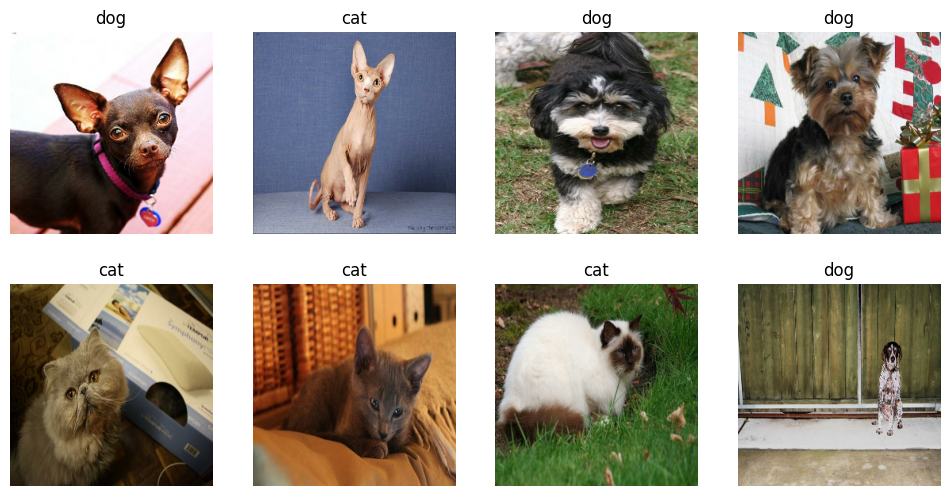

In [9]:
image_batch, label_batch = next(iter(train_ds)) # Obtenemos el primer lote de imágenes (32)

from matplotlib import pyplot as plt
plt.figure(figsize=(12, 6))
for i in range(8):  # Mostramos las 8 primeras imágenes del lote
  ax = plt.subplot(2, 4, i + 1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  label = label_batch[i]
  plt.title(class_names[label])
  plt.axis("off")

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Resizing, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomRotation, RandomTranslation, RandomZoom, RandomFlip, BatchNormalization

# define model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)), # Define los datos de entrada
    Resizing(IMAGE_SIZE, IMAGE_SIZE), # Integramos el escalado de las imágenes en el modelo
    Rescaling(1./255), # Normalizamos en el modelo
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'), # 148x148
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),strides=(2,2)), # 74x74

    Conv2D(filters=64, kernel_size=(3,3), activation='relu'), # 72x72
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2),strides=(2,2)), # 36x36

    Conv2D(filters=32, kernel_size=(3,3), activation='relu'), # 34x34
    MaxPooling2D(pool_size=(2,2),strides=(2,2)), # 17x17
    BatchNormalization(),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid') # La clasificación es binaria
])

In [11]:
# compile model
model.compile(optimizer = tf.optimizers.Adam(),
    loss = 'binary_crossentropy', # Función de pérdida en clasificación binaria
    metrics=['accuracy']
)

# Cuando no está predefinido el tamaño en el dataset (capa de entrada), hay que llamar a build y definirlo
# model.build(input_shape=(None,IMAGE_SIZE, IMAGE_SIZE, 3))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 17, 17, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,367,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,849 (9.26 MB)

 Trainable params: 2,426,017 (9.25 MB)

 Non-trainable params: 832 (3.25 KB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Monitoreamos la pérdida en la validación. Detenemos después de 6 iteraciones sin mejorar. Restauramos mejores pesos
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # Monitorea la pérdida en validación
    factor=0.5,           # Reduce la tasa de aprendizaje a la mitad
    patience=3,           # Espera 3 iteraciones sin mejora antes de reducir
    min_lr=1e-6           # No permite que la tasa de aprendizaje baje de 1e-6
)

# Pipeline optimizado y sin Warnings
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .ignore_errors() # Nueva versión
    .prefetch(buffer_size=AUTOTUNE)
)

validation_ds = (
    validation_ds
    .ignore_errors() # Nueva versión
    .prefetch(buffer_size=AUTOTUNE)
)

history = model.fit(train_ds,
        epochs = 30,
        validation_data=(validation_ds),
        callbacks=[early_stop, reduce_lr]  # Agregar ambas estrategias
)

Epoch 1/30
      7/Unknown 28s 3s/step - accuracy: 0.5577 - loss: 1.1345

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.5590 - loss: 1.1289 - val_accuracy: 0.4364 - val_loss: 0.7260 - learning_rate: 0.0010
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.7756 - loss: 0.5261 - val_accuracy: 0.5818 - val_loss: 0.6788 - learning_rate: 0.0010
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8785 - loss: 0.2776 - val_accuracy: 0.4727 - val_loss: 0.7203 - learning_rate: 0.0010
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.9700 - loss: 0.1462 - val_accuracy: 0.3818 - val_loss: 0.9370 - learning_rate: 0.0010
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.9875 - loss: 0.0906 - val_accuracy: 0.3818 - val_loss: 0.9014 - learning_rate: 0.0010
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.9963 - loss: 0.0592 - val_accuracy: 0.3818 - val_loss: 0.9324 - learning_rate: 5.0000e-04
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9696 - loss: 0.0923 - val_accuracy: 0.3818 - val_loss: 1.

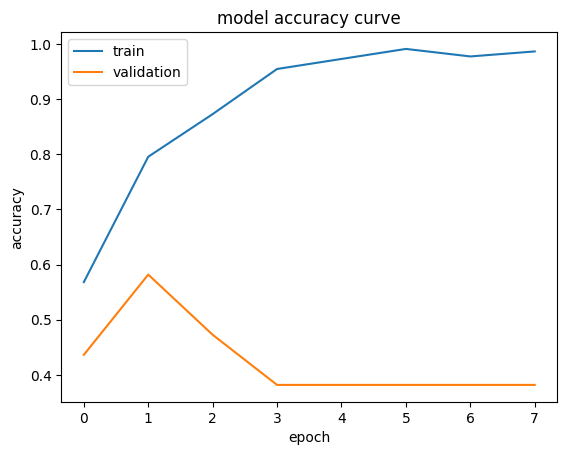

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy curve')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

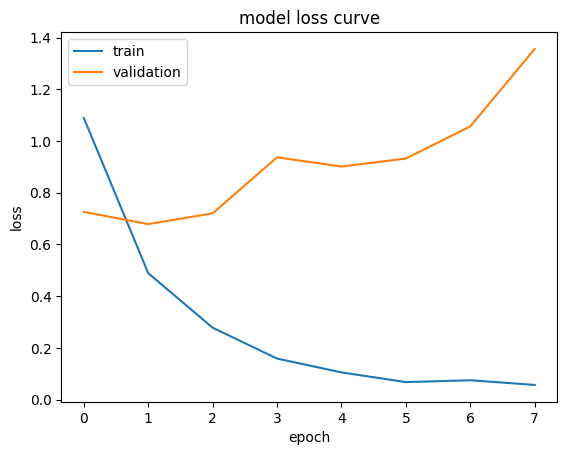

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss curve')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [15]:
predictions = model.evaluate(test_ds)
predictions

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step - accuracy: 0.6412 - loss: 0.6649


[0.682003915309906, 0.5714285969734192]

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 992ms/step


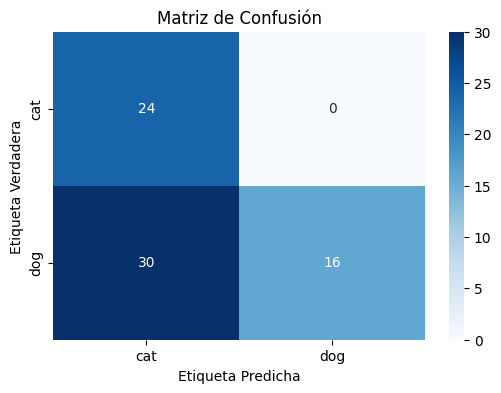

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

class_names = test_ds.class_names

pred = model.predict(test_ds)

pred_labels = (pred > 0.5).astype(int).ravel() # 0 o 1
true = np.concatenate([y for x, y in test_ds], axis=0)

cm = confusion_matrix(true, pred_labels)
labels = test_ds.class_names

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusión")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()

Número total de imágenes mal clasificadas: 30


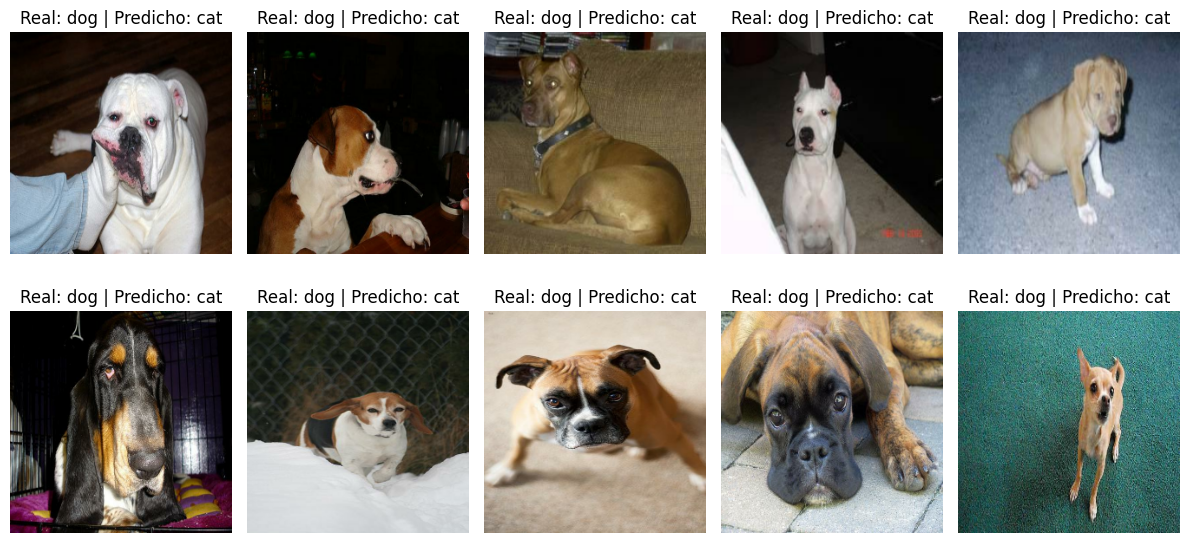

In [17]:
# Identificar los índices de las imágenes que se han clasificado incorrectamente
incorrect_indices = np.where(pred_labels != true)[0]

print("Número total de imágenes mal clasificadas:", len(incorrect_indices))
num_show=10
index_show=incorrect_indices[:num_show]
single_element_ds = test_ds.unbatch()

# # Obtener la imagen en la posición 36 (indexada desde 0)

plt.figure(figsize=(12, 6))
for i in range(len(index_show)):
    index = index_show[i];
    imagen, etiqueta = list(single_element_ds.skip(index).take(1))[0]
    plt.subplot(2, (num_show + 1) // 2, i + 1)
    plt.imshow(imagen.numpy().astype("uint8"))
    plt.title(f"Real: {class_names[etiqueta]} | Predicho: {class_names[pred_labels[index]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Clasificar imagen

In [18]:
import numpy as np
def classify(image_path):
  image = tf.keras.utils.load_img(image_path, color_mode='rgb')
  display(image)
  input_arr = tf.keras.utils.img_to_array(image)
  input_arr = np.array([input_arr])
  print(f'Tamaño de entrada: {input_arr.shape}')
  y_pred = model.predict(input_arr)
  print(f'Valores de salida: {y_pred[0][0]}')
  predicted_category_classname = class_names[round(y_pred[0][0])]
  print(f'Clasificación: {predicted_category_classname}')

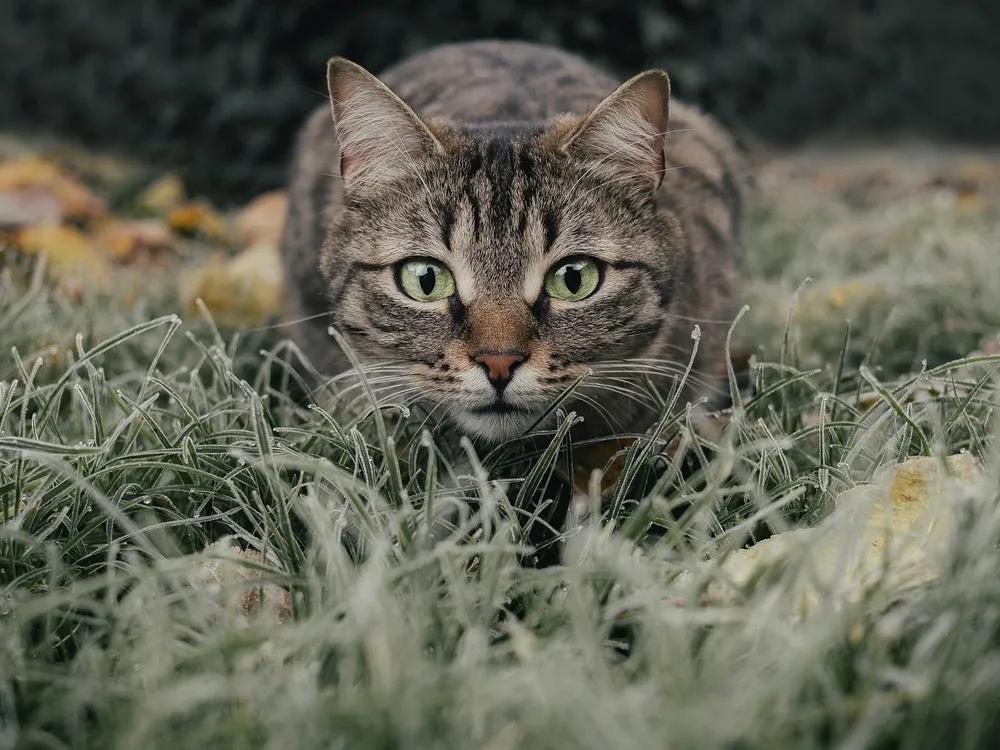

Tamaño de entrada: (1, 750, 1000, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
Valores de salida: 0.49505215883255005
Clasificación: cat


In [24]:
classify('cat3.jpg')